# Validación del historial de incendios EGIF

Valida los eventos oficiales de EGIF, su asignación a la rejilla de 1 km y la cobertura temporal del target. No genera archivos de imagen.

In [1]:
from pathlib import Path

import geopandas as gpd
import json
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white"})

EVENTS_PATH = Path("../data/processed/target/egif_events_2018_2023.gpkg")
TARGET_PATH = Path("../data/processed/target/egif_target_2018_2023.parquet")
METADATA_PATH = Path("../data/processed/target/egif_target_2018_2023_metadata.json")
GRID_PATH = Path("../data/processed/grid/grid_1km_topography_test.gpkg")

In [2]:
events = gpd.read_file(EVENTS_PATH)
target = pd.read_parquet(TARGET_PATH)
metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))

print(json.dumps(metadata, indent=2, ensure_ascii=False))
display(events.head())
display(target.head())

{
  "source": "EGIF-MITECO XML",
  "requested_period": {
    "start": "2018-01-01",
    "end": "2023-12-31"
  },
  "available_event_period": {
    "start": "2018-01-30",
    "end": "2023-11-26"
  },
  "n_events_galicia": 7719,
  "n_positive_cell_days": 7473,
  "warning": "The source ends before the requested period. Do not label subsequent dates as negatives."
}


,egif_id,fecha,anio,provincia,municipio,causa,superficie_ha,utm_zone,utm_x,utm_y,latitud,longitud,fuente_coordenadas,geometry
0,1237111,2018-02-24,2018,15,31,400,0.01,29,548005.0,4790216.0,43.263225,-8.408511,wgs84,POINT (2839308.699 2422518.414)
1,1237112,2018-02-25,2018,15,53,400,0.69,29,498542.0,4742796.0,42.837735,-9.017841,wgs84,POINT (2780332.852 2388786.344)
2,1237113,2018-02-25,2018,15,31,400,0.12,29,546429.0,4790073.0,43.262036,-8.427941,wgs84,POINT (2837750.69 2422775.121)
3,1237114,2018-02-25,2018,15,11,400,0.01,29,508440.0,4721848.0,42.649043,-8.897036,wgs84,POINT (2785001.025 2365896.621)
4,1237115,2018-02-25,2018,15,31,400,0.13,29,548983.0,4794508.0,43.301808,-8.396080,wgs84,POINT (2841264.518 2426451.134)


,cell_id,fecha,target_ignicion,n_incendios,superficie_ha
0,325,2022-08-17,1,1,1.10
1,326,2020-07-31,1,1,0.01
2,741,2021-03-06,1,1,3.40
3,933,2019-08-17,1,1,0.01
4,933,2022-09-08,1,1,0.01


In [3]:
assert events.crs.to_string() == "EPSG:3035"
assert set(target["target_ignicion"].unique()) == {1}
assert target["fecha"].min() >= pd.Timestamp("2018-01-01")

print(f"Eventos EGIF geolocalizados: {len(events):,}")
print(f"Positivos únicos celda-día: {len(target):,}")
print(f"Incendios agregados: {int(target['n_incendios'].sum()):,}")
print(f"Cobertura real: {target['fecha'].min():%Y-%m-%d} → {target['fecha'].max():%Y-%m-%d}")
if metadata["warning"]:
    print("AVISO:", metadata["warning"])

Eventos EGIF geolocalizados: 7,719
Positivos únicos celda-día: 7,473
Incendios agregados: 7,612
Cobertura real: 2018-01-30 → 2023-11-26
AVISO: The source ends before the requested period. Do not label subsequent dates as negatives.


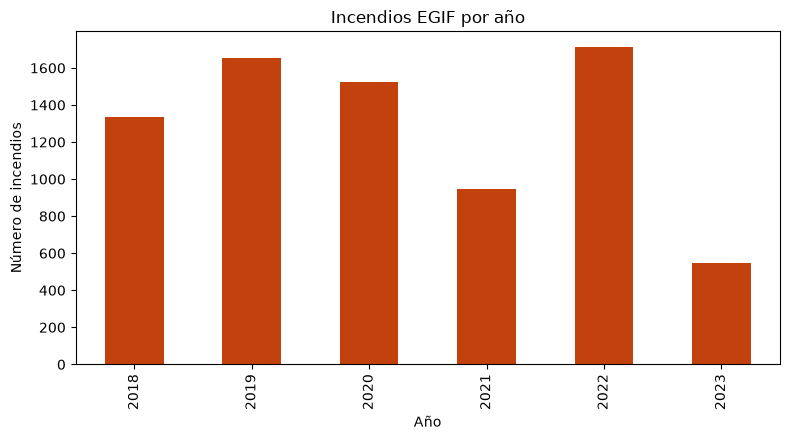

In [4]:
counts = events.groupby(events["fecha"].dt.year).size()
fig, ax = plt.subplots(figsize=(8, 4.5), facecolor="white")
counts.plot.bar(ax=ax, color="#c2410c")
ax.set_title("Incendios EGIF por año")
ax.set_xlabel("Año")
ax.set_ylabel("Número de incendios")
ax.set_facecolor("white")
plt.tight_layout()
plt.show()

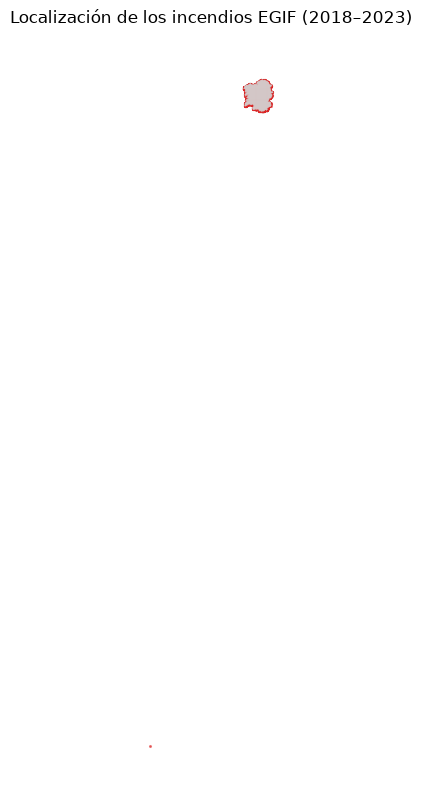

In [5]:
grid = gpd.read_file(GRID_PATH)
grid = grid.loc[grid["is_galicia"] == 1]

fig, ax = plt.subplots(figsize=(8, 8), facecolor="white")
grid.boundary.plot(ax=ax, linewidth=0.08, color="lightgrey")
events.plot(ax=ax, markersize=1.5, color="#dc2626", alpha=0.55)
ax.set_title("Localización de los incendios EGIF (2018–2023)")
ax.set_axis_off()
ax.set_facecolor("white")
plt.tight_layout()
plt.show()

In [6]:
events = None
target = None
grid = None

## Validación visual del contrato final

Esta celda comprueba que la variable existe en el cubo final y la representa sobre la máscara de Galicia con fondo blanco.

In [ ]:
import matplotlib.pyplot as plt
import xarray as xr
from src.config import DATACUBE_PATH

with xr.open_dataset(DATACUBE_PATH) as cube:
    date = cube.time.values[0]
    values = cube["target_ignicion"].sel(time=date).where(cube["is_galicia"] == 1)
    fig, ax = plt.subplots(figsize=(8, 8), facecolor="white")
    values.plot(ax=ax, cmap="Reds", add_colorbar=True)
    ax.set(title=f"Igniciones EGIF: {date}", facecolor="white")
    ax.set_aspect("equal")
    plt.show()